In [1]:
from insightface.app import FaceAnalysis
from detector import GenderAnalysis

In [ ]:
app = FaceAnalysis(allowed_modules=['detection', 'recognition', 'genderage'])
app.prepare(ctx_id=0, det_size=(320,320))

/home/eluna/miniconda3/envs/insightface/lib/python3.12/site-packages/onnxruntime/capi/onnxruntime_inference_collection.py:123: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(


Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
model ignore: /home/eluna/.insightface/models/buffalo_l/1k3d68.onnx landmark_3d_68
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
model ignore: /home/eluna/.insightface/models/buffalo_l/2d106det.onnx landmark_2d_106
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /home/eluna/.insightface/models/buffalo_l/det_10g.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /home/eluna/.insightface/models/buffalo_l/genderage.onnx genderage ['None', 3, 96, 96] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /home/eluna/.insightface/models/buffalo_l/w600k_r50.onnx recognition ['None', 3, 112, 112] 127.5 127.5
set det-size: (240, 240)


In [3]:
det = GenderAnalysis(app, gamma=3)

In [4]:
# det.process_and_save_errors('./img')

In [5]:
from pathlib import Path
path = Path('./people.pkl')

if not path.exists():
    det.embed_all('./img', 'people.pkl')

ValueError: operands could not be broadcast together with shapes (98,) (128,) 

In [ ]:
data = det.get_all_embeddings('people.pkl')

In [ ]:
result = det.evaluate_gender_accuracy()
# result = det.evaluate_lfw_gender_accuracy()

In [ ]:
if result:
    n_exitos, n_errores, pce_exitos, pce_errores = result
    print(f'exitos: {n_exitos}, errores: {n_errores}, pce exitos {pce_exitos}, pce errores {pce_errores}')

exitos: 14, errores: 4, pce exitos 77.77777777777779, pce errores 22.22222222222222


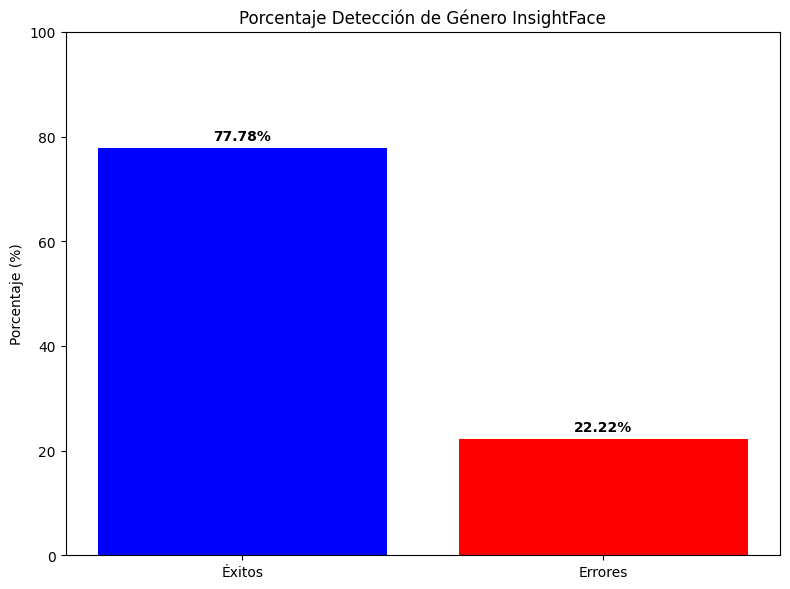

In [ ]:
det.plot_gender_accuracy(result)